# Informe Teórico Práctico 2: Regresión Lineal

SI3015 Fundamentos de Aprendizaje Automático, Universidad EAFIT, 2026

**Integrantes:** Julián Lara, Matías Martínez y Luis Alfonso Agudelo

**Dataset:** películas y series de IMDb (`movies dataset.csv`)


En este notebook resolvemos el punto 1.1 del taller. La idea es predecir el **rating de IMDb** de un título (película o serie) a partir de sus demás características, primero con una sola variable y después con varias.

**Concepto: regresión lineal.** Es un modelo supervisado que ajusta una recta (o un hiperplano cuando hay varias variables) de la forma $\hat{y} = b_0 + b_1 x_1 + \dots + b_n x_n$. Los coeficientes se escogen para que la suma de los errores al cuadrado sea la menor posible (mínimos cuadrados). Sirve para predecir valores numéricos continuos, y la usamos porque además de predecir deja leer cuánto aporta cada variable a través de su coeficiente.

## 1. Carga del dataset

El archivo tiene 9999 filas y 9 columnas: título, año, género, rating, sinopsis, reparto, votos, duración y recaudo. Antes de modelar hay que revisar cómo vienen los datos porque casi todas las columnas están guardadas como texto.

In [1]:
# Librerias que usamos en todo el notebook
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import GroupShuffleSplit
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 60)
SEMILLA = 42  # semilla fija para que los resultados se puedan repetir

In [2]:
# El csv esta en la raiz del repositorio, un nivel arriba de esta carpeta
df_raw = pd.read_csv("../movies dataset.csv")
print("Filas y columnas:", df_raw.shape)
df_raw.head()

Filas y columnas: (9999, 9)


,MOVIES,YEAR,GENRE,RATING,ONE-LINE,STARS,VOTES,RunTime,Gross
0,Blood Red Sky,(2021),"\nAction, Horror, Thriller",6.1,\nA woman with a mysterious illness is forced ...,\n Director:\nPeter Thorwarth\n| \n Star...,"21,062",121.0,NaN
1,Masters of the Universe: Revelation,(2021– ),"\nAnimation, Action, Adventure",5.0,\nThe war for Eternia begins again in what may...,"\n \n Stars:\nChris Wood, \nSara...","17,870",25.0,NaN
2,The Walking Dead,(2010–2022),"\nDrama, Horror, Thriller",8.2,\nSheriff Deputy Rick Grimes wakes up from a c...,"\n \n Stars:\nAndrew Lincoln, \n...","885,805",44.0,NaN
3,Rick and Morty,(2013– ),"\nAnimation, Adventure, Comedy",9.2,\nAn animated series that follows the exploits...,"\n \n Stars:\nJustin Roiland, \n...","414,849",23.0,NaN
4,Army of Thieves,(2021),"\nAction, Crime, Horror",NaN,"\nA prequel, set before the events of Army of ...",\n Director:\nMatthias Schweighöfer\n| \n ...,NaN,NaN,NaN


In [3]:
# Tipo de dato y cantidad de faltantes de cada columna tal como viene el archivo
resumen = pd.DataFrame({
    "tipo": df_raw.dtypes.astype(str),
    "faltantes": df_raw.isna().sum(),
    "% faltantes": (df_raw.isna().mean() * 100).round(1),
})
resumen

,tipo,faltantes,% faltantes
MOVIES,str,0,0.0
YEAR,str,644,6.4
GENRE,str,80,0.8
RATING,float64,1820,18.2
ONE-LINE,str,0,0.0
STARS,str,0,0.0
VOTES,str,1820,18.2
RunTime,float64,2958,29.6
Gross,str,9539,95.4


In [4]:
# Asi se ve una fila por dentro: saltos de linea, espacios de relleno y varios datos en un mismo campo
for col in ["YEAR", "GENRE", "STARS", "VOTES", "Gross"]:
    print(f"{col:6}: {df_raw.loc[0, col]!r}")

YEAR  : '(2021)'
GENRE : '\nAction, Horror, Thriller            '
STARS : '\n    Director:\nPeter Thorwarth\n| \n    Stars:\nPeri Baumeister, \nCarl Anton Koch, \nAlexander Scheer, \nKais Setti\n'
VOTES : '21,062'
Gross : nan


## 2. Limpieza y transformación

Encontramos estos problemas en el archivo original:

1. Los campos de texto traen saltos de línea y espacios sobrantes.
2. `YEAR` mezcla el año con el tipo de producción, por ejemplo `(2021)`, `(2019– )` para una serie que sigue al aire, `(2005–2014)` para una serie terminada o `(2020 TV Special)`.
3. `VOTES` es texto con comas de miles y `Gross` es texto con el signo `$` y la letra `M`.
4. `STARS` junta director y actores en un solo campo.
5. Hay filas repetidas exactas.
6. Muchos títulos aparecen varias veces con distinto rating. Revisando, son episodios de una misma serie (por ejemplo `13 Reasons Why` aparece más de 30 veces).

La función de abajo resuelve todo eso y crea variables nuevas a partir del texto.

In [5]:
def limpiar_peliculas(df_raw):
    df = df_raw.copy()

    # Nombres cortos y en espanol para trabajar mas comodo
    df = df.rename(columns={
        "MOVIES": "titulo", "YEAR": "anio_texto", "GENRE": "genero", "RATING": "rating",
        "ONE-LINE": "sinopsis", "STARS": "reparto", "VOTES": "votos_texto",
        "RunTime": "duracion", "Gross": "recaudo_texto",
    })

    # Quitamos saltos de linea y espacios repetidos en los campos de texto
    for col in ["titulo", "anio_texto", "genero", "sinopsis", "reparto"]:
        df[col] = df[col].str.replace(r"\s+", " ", regex=True).str.strip()

    # Filas repetidas exactas
    n_antes = len(df)
    df = df.drop_duplicates().reset_index(drop=True)
    print("Filas duplicadas eliminadas:", n_antes - len(df))

    # Del texto del anio sacamos: anio de inicio, si es serie, si sigue al aire y el tipo
    anio = df["anio_texto"].fillna("")
    df["anio_inicio"] = pd.to_numeric(anio.str.extract(r"(\d{4})")[0])
    df["es_serie"] = anio.str.contains("–").astype(int)
    df["en_emision"] = anio.str.contains(r"–\s*\)").astype(int)
    df["tipo"] = np.select(
        [anio.str.contains("–"), anio.str.contains("TV Special"), anio.str.contains("TV Movie"),
         anio.str.contains("Video"), anio.str.contains("TV Short")],
        ["Serie", "Especial TV", "Pelicula TV", "Video", "Corto TV"],
        default="Pelicula",
    )

    # Votos y recaudo pasan de texto a numero
    df["votos"] = pd.to_numeric(df["votos_texto"].str.replace(",", ""), errors="coerce")
    df["recaudo_millones"] = pd.to_numeric(
        df["recaudo_texto"].str.replace(r"[$M]", "", regex=True), errors="coerce")

    # Del reparto sacamos si hay director registrado y cuantos actores aparecen
    df["tiene_director"] = df["reparto"].str.contains("Director").astype(int)
    actores = df["reparto"].str.extract(r"Stars?:(.*)")[0].fillna("")
    df["n_actores"] = actores.apply(lambda s: len([a for a in s.split(",") if a.strip()]))

    # Cantidad de generos que tiene cada titulo
    df["n_generos"] = df["genero"].fillna("").apply(
        lambda s: len([g for g in s.split(",") if g.strip()]))

    # "Add a Plot" significa que IMDb no tiene sinopsis, lo marcamos aparte
    df["sin_sinopsis"] = (df["sinopsis"] == "Add a Plot").astype(int)
    df["largo_sinopsis"] = np.where(df["sin_sinopsis"] == 1, 0, df["sinopsis"].str.split().str.len())

    # Un titulo repetido corresponde a episodios de una misma serie
    conteo = df["titulo"].value_counts()
    df["es_episodio"] = (df["titulo"].map(conteo) > 1).astype(int)

    return df


df = limpiar_peliculas(df_raw)
df[["titulo", "anio_inicio", "tipo", "es_serie", "en_emision", "rating", "votos",
    "duracion", "tiene_director", "n_actores", "n_generos", "es_episodio"]].head(8)

Filas duplicadas eliminadas: 431


,titulo,anio_inicio,tipo,es_serie,en_emision,rating,votos,duracion,tiene_director,n_actores,n_generos,es_episodio
0,Blood Red Sky,2021.0,Pelicula,0,0,6.1,21062.0,121.0,1,4,3,0
1,Masters of the Universe: Revelation,2021.0,Serie,1,1,5.0,17870.0,25.0,0,4,3,1
2,The Walking Dead,2010.0,Serie,1,0,8.2,885805.0,44.0,0,4,3,0
3,Rick and Morty,2013.0,Serie,1,1,9.2,414849.0,23.0,0,4,3,1
4,Army of Thieves,2021.0,Pelicula,0,0,NaN,NaN,NaN,1,4,3,0
5,Outer Banks,2020.0,Serie,1,1,7.6,25858.0,50.0,0,4,3,1
6,The Last Letter from Your Lover,2021.0,Pelicula,0,0,6.8,5283.0,110.0,1,4,2,0
7,Dexter,2006.0,Serie,1,0,8.6,665387.0,53.0,0,4,3,1


In [6]:
# Faltantes despues de la limpieza en las columnas que nos interesan
cols = ["rating", "votos", "duracion", "anio_inicio", "genero", "recaudo_millones"]
(df[cols].isna().mean() * 100).round(1).to_frame("% faltantes")

,% faltantes
rating,14.6
votos,14.6
duracion,26.8
anio_inicio,6.6
genero,0.8
recaudo_millones,95.2


Con esos porcentajes tomamos varias decisiones:

1. **Recaudo:** le falta cerca del 95 % de los datos. Imputar tanto sería inventar la columna, así que no la usamos.
2. **Rating:** es la variable objetivo, y sin ella la fila no sirve para entrenar. Esas filas se eliminan. Casi siempre son títulos que todavía no se estrenan, porque tampoco tienen votos.
3. **Duración:** entre las filas que sí tienen rating le falta alrededor del 17 %. La llenamos con la mediana de su tipo, porque un episodio de serie dura mucho menos que una película y una mediana general mezclaría las dos cosas. También guardamos una columna que indica que el dato era faltante.
4. **Votos:** van desde 5 hasta casi dos millones y la distribución es muy asimétrica. Aplicamos `log(1 + votos)` para comprimir la escala.
5. **Género y tipo:** son categóricas, así que las pasamos a columnas 0/1 (one hot). Un título puede tener varios géneros a la vez.

In [7]:
def preparar_para_modelos(df):
    # Sin rating no hay objetivo, esas filas no sirven para entrenar
    d = df.dropna(subset=["rating"]).copy()

    # Duracion faltante: mediana de su mismo tipo y una bandera que indica que faltaba
    d["duracion_faltante"] = d["duracion"].isna().astype(int)
    d["duracion"] = d["duracion"].fillna(d.groupby("tipo")["duracion"].transform("median"))
    d["duracion"] = d["duracion"].fillna(d["duracion"].median())
    d["anio_inicio"] = d["anio_inicio"].fillna(d["anio_inicio"].median())

    # Logaritmo de los votos para reducir la asimetria
    d["log_votos"] = np.log1p(d["votos"])

    # Generos en formato one hot, una columna por genero
    generos = d["genero"].fillna("").str.get_dummies(sep=", ")
    generos.columns = ["gen_" + c.replace("-", "_") for c in generos.columns]

    # Tipo en one hot. Serie ya esta en es_serie y Pelicula queda como categoria base
    tipos = pd.get_dummies(d["tipo"], prefix="tipo", dtype=int)
    tipos.columns = [c.replace(" ", "_") for c in tipos.columns]
    tipos = tipos.drop(columns=["tipo_Serie", "tipo_Pelicula"])

    d = pd.concat([d, generos, tipos], axis=1).reset_index(drop=True)
    return d, list(generos.columns), list(tipos.columns)


d, cols_generos, cols_tipos = preparar_para_modelos(df)
print("Filas disponibles para modelar:", d.shape[0])
print("Columnas de genero:", len(cols_generos), "| columnas de tipo:", cols_tipos)

Filas disponibles para modelar: 8168
Columnas de genero: 27 | columnas de tipo: ['tipo_Corto_TV', 'tipo_Especial_TV', 'tipo_Pelicula_TV', 'tipo_Video']


## 3. Análisis exploratorio

**Concepto: estadística descriptiva.** Antes de entrenar hay que entender los datos: el centro (media y mediana), la dispersión (desviación estándar e IQR) y los valores atípicos. Para los atípicos usamos la regla de 1.5 veces el IQR vista en clase. El **IQR ratio** (IQR dividido por el rango) indica si una columna es casi constante (menos de 0.05) o si tiene una dispersión muy grande (más de 0.9).

In [8]:
# Medidas de tendencia central y dispersion de las variables numericas
d[["rating", "duracion", "votos", "anio_inicio", "n_actores", "n_generos", "largo_sinopsis"]].describe().round(2)

,rating,duracion,votos,anio_inicio,n_actores,n_generos,largo_sinopsis
count,8168.00,8168.00,8168.00,8168.00,8168.00,8168.00,8168.00
mean,6.92,66.61,15144.41,2015.83,3.68,2.26,25.15
std,1.22,44.86,70099.54,7.57,0.94,0.84,9.63
min,1.10,1.00,5.00,1932.00,0.00,0.00,0.00
25%,6.20,38.00,167.00,2015.00,4.00,1.00,20.00
50%,7.10,55.00,792.50,2018.00,4.00,3.00,25.00
75%,7.80,94.00,3780.75,2020.00,4.00,3.00,32.00
max,9.90,853.00,1713028.00,2021.00,4.00,3.00,72.00


In [9]:
def resumen_iqr(serie):
    # Rango intercuartilico, limites de outliers e IQR ratio como se vio en clase
    q1, q3 = serie.quantile([0.25, 0.75])
    iqr = q3 - q1
    lim_inf, lim_sup = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    return pd.Series({
        "Q1": q1, "Q3": q3, "IQR": iqr, "lim_inf": lim_inf, "lim_sup": lim_sup,
        "outliers": int(((serie < lim_inf) | (serie > lim_sup)).sum()),
        "IQR_ratio": iqr / (serie.max() - serie.min()),
    })


num = ["rating", "duracion", "votos", "log_votos", "anio_inicio", "n_actores", "n_generos", "largo_sinopsis"]
d[num].apply(resumen_iqr).T.round(3)

,Q1,Q3,IQR,lim_inf,lim_sup,outliers,IQR_ratio
rating,6.200,7.800,1.600,3.800,10.200,165.0,0.182
duracion,38.000,94.000,56.000,-46.000,178.000,116.0,0.066
votos,167.000,3780.750,3613.750,-5253.625,9201.375,1298.0,0.002
log_votos,5.124,8.238,3.114,0.453,12.909,43.0,0.248
anio_inicio,2015.000,2020.000,5.000,2007.500,2027.500,681.0,0.056
n_actores,4.000,4.000,0.000,4.000,4.000,952.0,0.000
n_generos,1.000,3.000,2.000,-2.000,6.000,0.0,0.667
largo_sinopsis,20.000,32.000,12.000,2.000,50.000,377.0,0.167


El IQR ratio de `votos` es prácticamente cero: el 50 % central de los datos está en un rango muy pequeño comparado con el máximo, y aparecen más de mil outliers. Después del logaritmo el IQR ratio queda en un valor sano, que es justo lo que buscábamos con esa transformación.

`n_actores` tiene IQR igual a cero porque la gran mayoría de títulos muestra exactamente 4 actores (es lo que IMDb deja ver en el listado). Según la recomendación de clase es una columna casi plana y aporta poca información. La dejamos por ahora y en el caso 2 se verá si sirve o no. El IQR ratio bajo de `duracion` y `anio_inicio` no viene de que sean columnas planas sino de unos pocos valores extremos que estiran el rango.

En `duracion` los outliers son reales: miniseries o especiales que duran varias horas y episodios de pocos minutos. No son errores de digitación, así que los dejamos. El rating tiene outliers por debajo (títulos con notas de 1 o 2), que también son válidos.

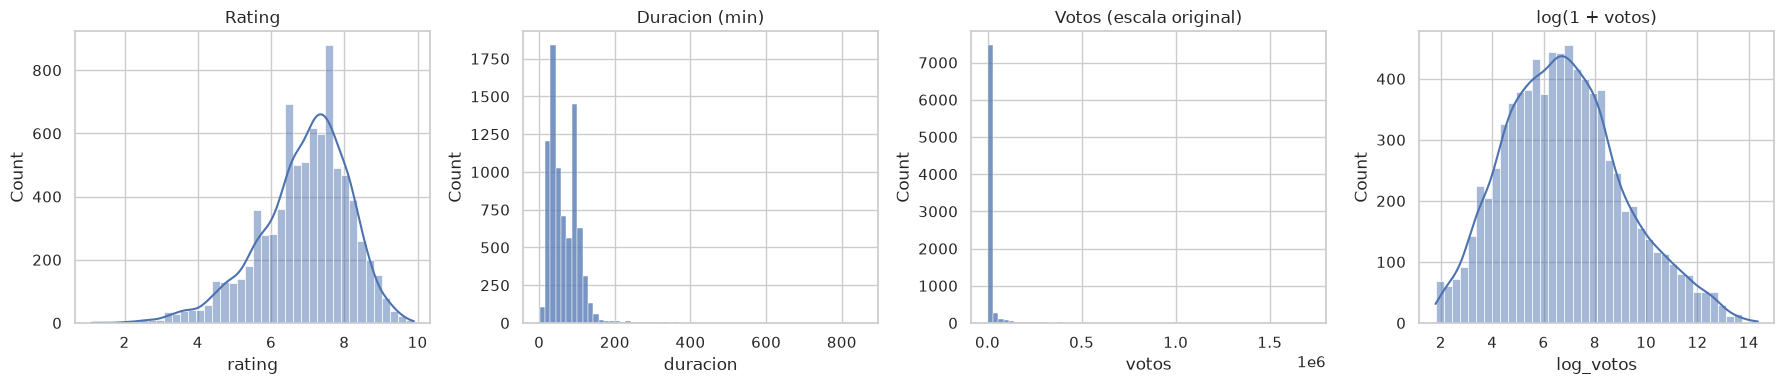

In [10]:
# Distribucion del rating (objetivo) y de las variables mas importantes
fig, ejes = plt.subplots(1, 4, figsize=(18, 4))
sns.histplot(d["rating"], bins=40, kde=True, ax=ejes[0]).set_title("Rating")
sns.histplot(d["duracion"], bins=60, ax=ejes[1]).set_title("Duracion (min)")
sns.histplot(d["votos"], bins=60, ax=ejes[2]).set_title("Votos (escala original)")
sns.histplot(d["log_votos"], bins=40, kde=True, ax=ejes[3]).set_title("log(1 + votos)")
plt.tight_layout()
plt.show()

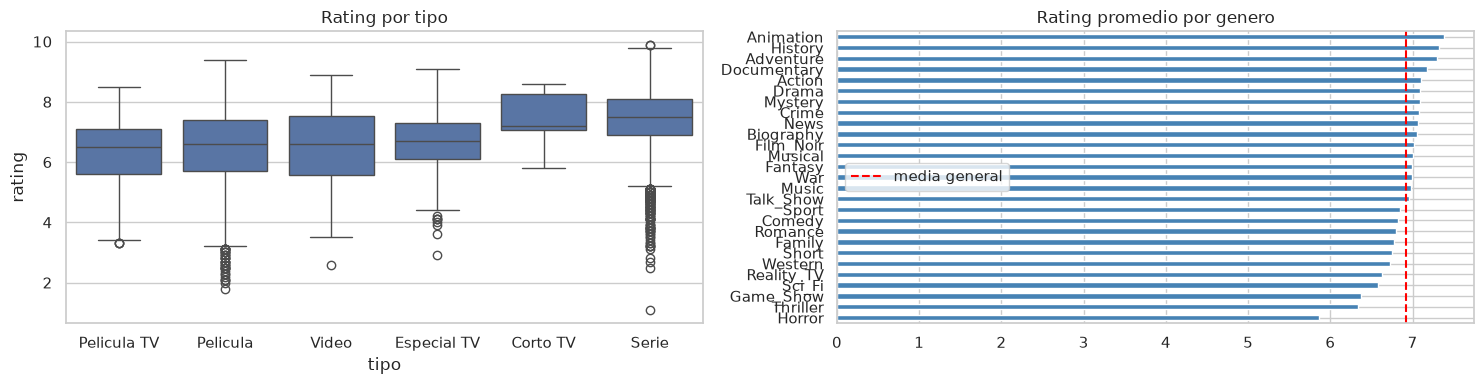

In [11]:
# Rating segun el tipo de produccion
fig, ejes = plt.subplots(1, 2, figsize=(15, 4))
orden = d.groupby("tipo")["rating"].median().sort_values().index
sns.boxplot(data=d, x="tipo", y="rating", order=orden, ax=ejes[0])
ejes[0].set_title("Rating por tipo")

# Rating promedio por genero
media_genero = pd.Series({g.replace("gen_", ""): d.loc[d[g] == 1, "rating"].mean() for g in cols_generos}).sort_values()
media_genero.plot(kind="barh", ax=ejes[1], color="steelblue")
ejes[1].axvline(d["rating"].mean(), color="red", ls="--", label="media general")
ejes[1].set_title("Rating promedio por genero")
ejes[1].legend()
plt.tight_layout()
plt.show()

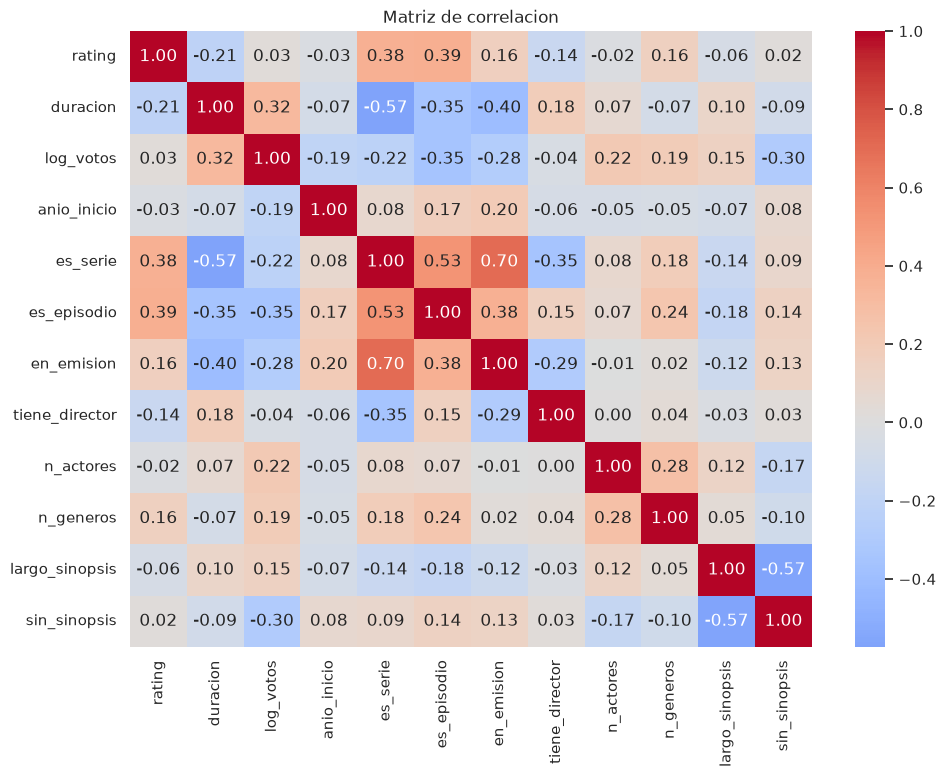

In [12]:
# Correlacion de Pearson entre las variables numericas y el rating
cols_corr = ["rating", "duracion", "log_votos", "anio_inicio", "es_serie", "es_episodio",
             "en_emision", "tiene_director", "n_actores", "n_generos", "largo_sinopsis", "sin_sinopsis"]
plt.figure(figsize=(11, 8))
sns.heatmap(d[cols_corr].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Matriz de correlacion")
plt.show()

Lo que sacamos del análisis exploratorio:

1. El rating está concentrado entre 6 y 8 (mediana cercana a 7.1) y tiene una cola larga hacia notas bajas.
2. Las series tienen mejor rating que las películas, y los episodios todavía más. Tiene sentido: quien califica un episodio suele ser alguien que ya sigue la serie.
3. Por género también hay diferencias claras: terror y thriller quedan muy por debajo del promedio, mientras que animación, historia y aventura quedan por encima.
4. Ninguna variable tiene una correlación fuerte con el rating. Las más altas son `es_episodio` y `es_serie` (cerca de 0.38), y la duración tiene una correlación negativa de más o menos 0.21. Los votos, que uno pensaría que importan mucho, casi no se correlacionan con la nota. Con esto ya se ve venir que una sola variable va a explicar poco.

### División entrenamiento y prueba

**Concepto.** Separar los datos en entrenamiento y prueba sirve para medir el modelo con datos que nunca vio. Si se evalúa con los mismos datos del entrenamiento, las métricas salen infladas.

Aquí hay un detalle propio de este dataset: los episodios de una misma serie tienen el mismo título, una duración parecida y votos parecidos. Con una división aleatoria normal, unos episodios caen en entrenamiento y otros en prueba, y el modelo termina reconociendo la serie en vez de aprender algo general. Por eso usamos `GroupShuffleSplit` agrupando por título: todos los episodios de una serie quedan del mismo lado. Dejamos el 80 % para entrenar y el 20 % para probar.

In [13]:
# Division 80/20 agrupando por titulo para que una serie no quede repartida en ambos conjuntos
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=SEMILLA)
idx_train, idx_test = next(gss.split(d, groups=d["titulo"]))
train, test = d.iloc[idx_train].copy(), d.iloc[idx_test].copy()

print("Entrenamiento:", train.shape[0], "filas")
print("Prueba:", test.shape[0], "filas")
print("Titulos compartidos entre ambos:", len(set(train["titulo"]) & set(test["titulo"])))

Entrenamiento: 6447 filas
Prueba: 1721 filas
Titulos compartidos entre ambos: 0


### Métricas de evaluación

**R² (coeficiente de determinación):** mide qué proporción de la variación del rating logra explicar el modelo. Vale 1 si el modelo es perfecto y 0 si no mejora a predecir siempre el promedio. En datos nuevos puede salir negativo.

**MSE (error cuadrático medio):** es $\frac{1}{n}\sum (y_i - \hat{y}_i)^2$, el promedio de los errores al cuadrado. Castiga más los errores grandes. Reportamos también el **RMSE**, su raíz, que queda en las mismas unidades del rating y es más fácil de interpretar.

**R:** coeficiente de correlación entre el valor real y el predicho. En regresión lineal con intercepto, en entrenamiento se cumple que $R^2 = R \cdot R$.

In [14]:
def evaluar_regresion(columnas, nombre):
    # Entrena una regresion lineal con las columnas dadas y devuelve el modelo, las predicciones y las metricas
    modelo = LinearRegression()
    modelo.fit(train[columnas], train["rating"])
    pred_train = modelo.predict(train[columnas])
    pred = modelo.predict(test[columnas])
    mse = mean_squared_error(test["rating"], pred)
    metricas = {
        "modelo": nombre,
        "n_variables": len(columnas),
        "R": np.corrcoef(test["rating"], pred)[0, 1],
        "R2_train": r2_score(train["rating"], pred_train),
        "R2_test": r2_score(test["rating"], pred),
        "MSE_test": mse,
        "RMSE_test": np.sqrt(mse),
    }
    return modelo, pred, metricas


# Referencia: predecir siempre el promedio del entrenamiento
pred_base = np.full(len(test), train["rating"].mean())
mse_base = mean_squared_error(test["rating"], pred_base)
print(f"Modelo base (siempre el promedio): MSE = {mse_base:.3f}, RMSE = {np.sqrt(mse_base):.3f}")

Modelo base (siempre el promedio): MSE = 1.541, RMSE = 1.241


## 4. Caso 1: regresión lineal simple

**Enunciado.** Aplicar regresión lineal seleccionando una única columna característica y una variable objetivo, obtener métricas de desempeño (R, MSE), redactar los procesos relevantes y sacar conclusiones.

**Variable objetivo:** `rating`.

**Variable característica:** `duracion`. De las variables continuas es la que más se correlaciona con el rating (correlación negativa). `es_serie` y `es_episodio` tienen una correlación mayor, pero son binarias, y con ella la "recta" solo produciría dos valores posibles. Con la duración sí tiene sentido hablar de una recta.

In [15]:
modelo_1, pred_1, met_1 = evaluar_regresion(["duracion"], "Caso 1: duracion")

print(f"Intercepto: {modelo_1.intercept_:.4f}")
print(f"Coeficiente de duracion: {modelo_1.coef_[0]:.5f}")
pd.DataFrame([met_1]).round(4)

Intercepto: 7.2669
Coeficiente de duracion: -0.00549


,modelo,n_variables,R,R2_train,R2_test,MSE_test,RMSE_test
0,Caso 1: duracion,1,0.2562,0.0404,0.0579,1.4421,1.2009


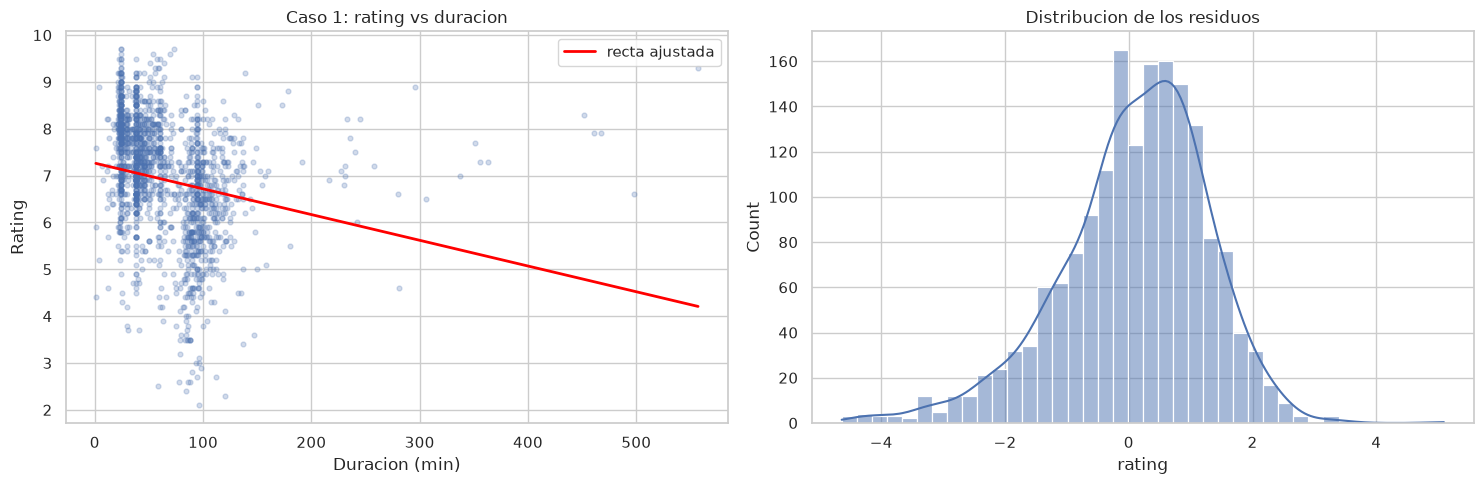

In [16]:
# Recta ajustada sobre los datos de prueba
x_linea = np.linspace(test["duracion"].min(), test["duracion"].max(), 100)
y_linea = modelo_1.intercept_ + modelo_1.coef_[0] * x_linea

fig, ejes = plt.subplots(1, 2, figsize=(15, 5))
ejes[0].scatter(test["duracion"], test["rating"], alpha=0.25, s=12)
ejes[0].plot(x_linea, y_linea, color="red", lw=2, label="recta ajustada")
ejes[0].set_xlabel("Duracion (min)")
ejes[0].set_ylabel("Rating")
ejes[0].set_title("Caso 1: rating vs duracion")
ejes[0].legend()

# Residuos: diferencia entre el valor real y el predicho
residuos_1 = test["rating"] - pred_1
sns.histplot(residuos_1, bins=40, kde=True, ax=ejes[1])
ejes[1].set_title("Distribucion de los residuos")
plt.tight_layout()
plt.show()

### Conclusiones del caso 1

El coeficiente de la duración es negativo (alrededor de 0.0055 por minuto), es decir, por cada 100 minutos más de duración el modelo baja el rating unos 0.55 puntos. Esto cuadra con lo visto en el análisis exploratorio: los episodios cortos de series tienen mejor nota que las películas largas.

Aun así el modelo es muy pobre. El R² en prueba es de apenas 0.058, o sea que la duración explica cerca del 6 % de la variación del rating. El MSE baja de 1.541 (predecir siempre el promedio) a 1.442, y el RMSE queda en 1.20 puntos de rating, casi igual a la desviación estándar de la variable. En la gráfica se ve una nube de puntos sin forma de recta, y la recta ajustada es casi plana.

La conclusión es que el rating no depende linealmente de una sola variable. Con una columna se alcanza a ver la tendencia, pero no sirve para predecir.

## 5. Caso 2: regresión lineal múltiple

**Enunciado.** Aplicar regresión lineal seleccionando dos columnas características y una variable objetivo, obtener métricas de desempeño (R, MSE) y agregar las columnas que sean necesarias para mejorar las métricas.

**Concepto: regresión lineal múltiple.** Es la misma idea del caso anterior pero con varias variables de entrada. Cada coeficiente dice cuánto cambia el rating cuando esa variable aumenta en una unidad y las demás se quedan quietas.

Empezamos con `duracion` y `log_votos` y después vamos agregando grupos de variables en este orden:

1. **Estructura del título:** si es serie, si es episodio y si sigue al aire.
2. **Datos adicionales:** año de inicio, si tiene director, número de actores, número de géneros, largo de la sinopsis, si le falta sinopsis y si le faltaba la duración.
3. **Géneros y tipo de producción** en formato one hot.

Como la regresión lineal por mínimos cuadrados no depende de la escala de las variables, no hace falta escalar. Lo que sí hicimos fue el logaritmo de los votos, porque sin él unos pocos títulos gigantes dominarían la recta.

In [17]:
# Grupos de variables que vamos agregando por pasos
vars_estructura = ["es_serie", "es_episodio", "en_emision"]
vars_extra = ["anio_inicio", "tiene_director", "n_actores", "n_generos",
              "largo_sinopsis", "sin_sinopsis", "duracion_faltante"]
todas = ["duracion", "log_votos"] + vars_estructura + vars_extra + cols_generos + cols_tipos

pasos = {
    "Paso A: duracion + log_votos": ["duracion", "log_votos"],
    "Paso B: + estructura": ["duracion", "log_votos"] + vars_estructura,
    "Paso C: + datos adicionales": ["duracion", "log_votos"] + vars_estructura + vars_extra,
    "Paso D: + generos y tipo": todas,
}

resultados = [met_1]
modelos = {}
for nombre, columnas in pasos.items():
    modelo, pred, met = evaluar_regresion(columnas, nombre)
    modelos[nombre] = (modelo, pred, columnas)
    resultados.append(met)

tabla = pd.DataFrame(resultados).set_index("modelo").round(4)
tabla

,n_variables,R,R2_train,R2_test,MSE_test,RMSE_test
modelo,,,,,,
Caso 1: duracion,1,0.2562,0.0404,0.0579,1.4421,1.2009
Paso A: duracion + log_votos,2,0.2764,0.0525,0.0680,1.4267,1.1945
Paso B: + estructura,5,0.5538,0.2228,0.3012,1.0697,1.0342
Paso C: + datos adicionales,12,0.5709,0.2589,0.3202,1.0407,1.0201
Paso D: + generos y tipo,43,0.6519,0.3661,0.4198,0.8882,0.9424


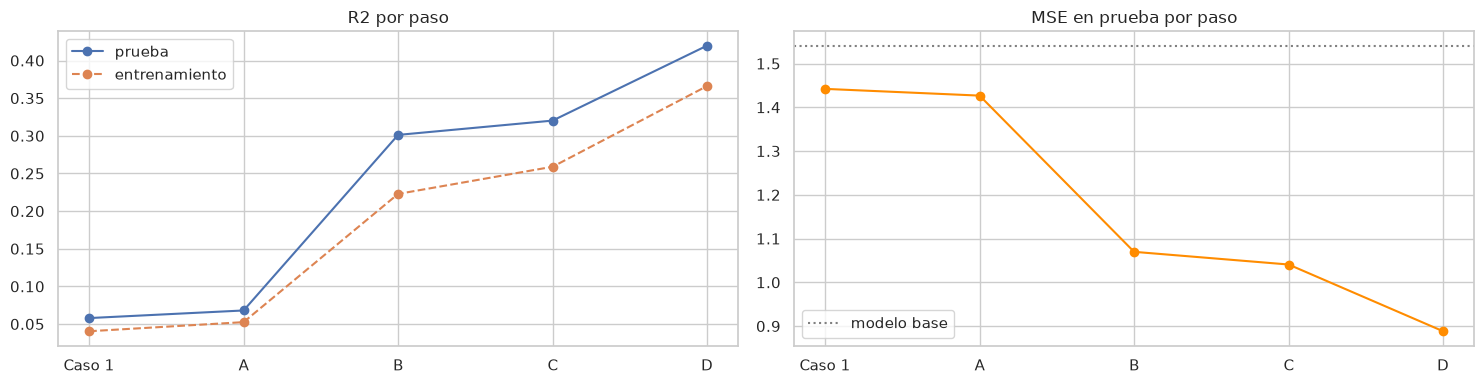

In [18]:
# Evolucion de R2 y MSE a medida que se agregan variables
fig, ejes = plt.subplots(1, 2, figsize=(15, 4))
etiquetas = ["Caso 1", "A", "B", "C", "D"]
ejes[0].plot(etiquetas, tabla["R2_test"], marker="o", label="prueba")
ejes[0].plot(etiquetas, tabla["R2_train"], marker="o", ls="--", label="entrenamiento")
ejes[0].set_title("R2 por paso")
ejes[0].legend()
ejes[1].plot(etiquetas, tabla["MSE_test"], marker="o", color="darkorange")
ejes[1].axhline(mse_base, color="gray", ls=":", label="modelo base")
ejes[1].set_title("MSE en prueba por paso")
ejes[1].legend()
plt.tight_layout()
plt.show()

In [19]:
# Resultado del paso A (solo dos variables)
modelo_a, pred_a, cols_a = modelos["Paso A: duracion + log_votos"]
print("Intercepto:", round(modelo_a.intercept_, 4))
print(pd.Series(modelo_a.coef_, index=cols_a).round(5))

Intercepto: 6.9171
duracion    -0.00647
log_votos    0.06062
dtype: float64


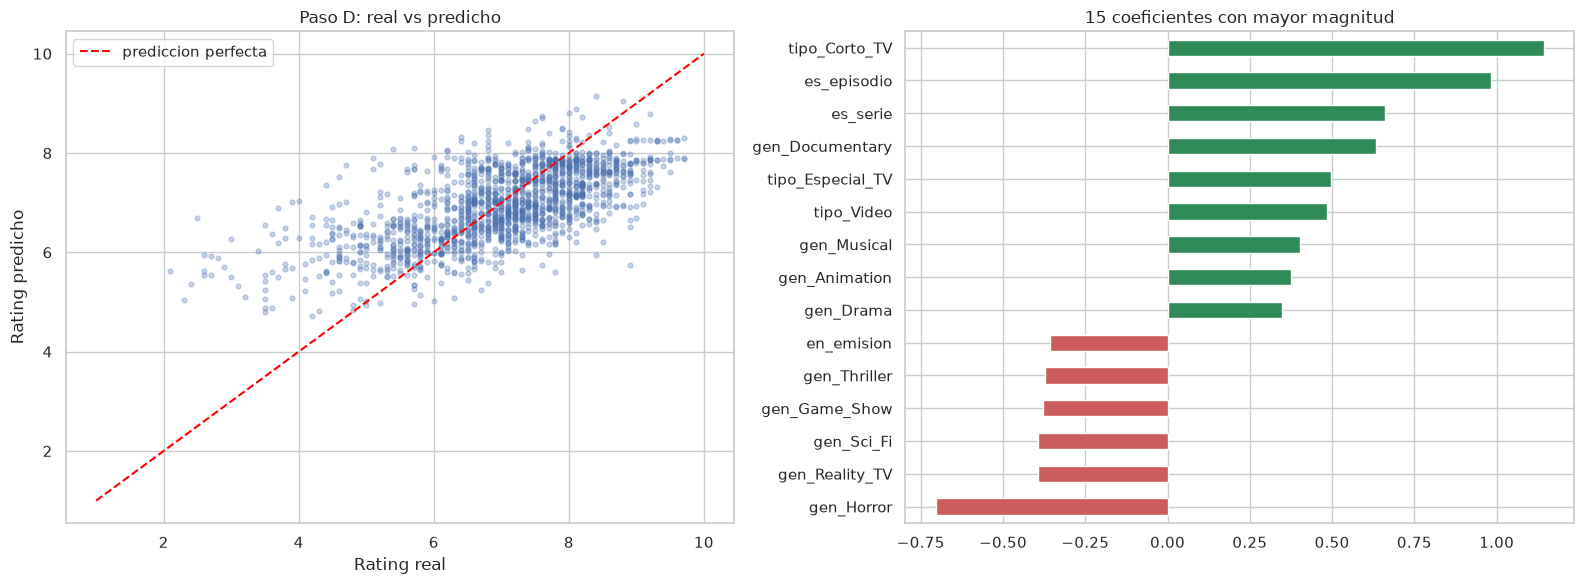

In [20]:
# Modelo final (paso D): real vs predicho y coeficientes mas grandes
modelo_d, pred_d, cols_d = modelos["Paso D: + generos y tipo"]

fig, ejes = plt.subplots(1, 2, figsize=(16, 6))
ejes[0].scatter(test["rating"], pred_d, alpha=0.3, s=12)
ejes[0].plot([1, 10], [1, 10], color="red", ls="--", label="prediccion perfecta")
ejes[0].set_xlabel("Rating real")
ejes[0].set_ylabel("Rating predicho")
ejes[0].set_title("Paso D: real vs predicho")
ejes[0].legend()

coef = pd.Series(modelo_d.coef_, index=cols_d)
top = coef.reindex(coef.abs().sort_values(ascending=False).index).head(15).sort_values()
top.plot(kind="barh", ax=ejes[1], color=np.where(top > 0, "seagreen", "indianred"))
ejes[1].set_title("15 coeficientes con mayor magnitud")
plt.tight_layout()
plt.show()

### Análisis de residuos del modelo final

**Concepto: residuo.** Es la diferencia entre el rating real y el predicho. Si el modelo está bien planteado, los residuos deberían quedar repartidos alrededor de cero sin ningún patrón. Si se ve una forma (una tendencia o un embudo), el modelo se equivoca de manera sistemática en alguna zona.

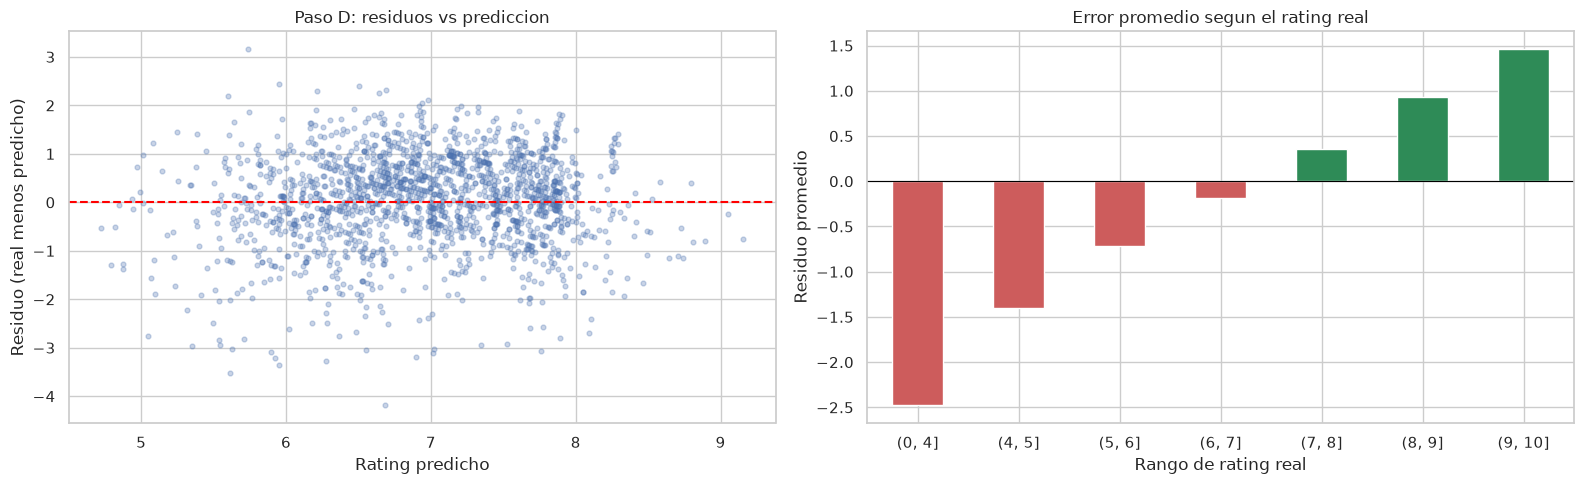

rating
(0, 4]    -2.476
(4, 5]    -1.400
(5, 6]    -0.712
(6, 7]    -0.189
(7, 8]     0.360
(8, 9]     0.931
(9, 10]    1.461
Name: rating, dtype: float64


In [21]:
# Residuos del paso D contra la prediccion y residuo promedio segun el rating real
residuos_d = test["rating"] - pred_d

fig, ejes = plt.subplots(1, 2, figsize=(16, 5))
ejes[0].scatter(pred_d, residuos_d, alpha=0.3, s=12)
ejes[0].axhline(0, color="red", ls="--")
ejes[0].set_xlabel("Rating predicho")
ejes[0].set_ylabel("Residuo (real menos predicho)")
ejes[0].set_title("Paso D: residuos vs prediccion")

rangos = pd.cut(test["rating"], bins=[0, 4, 5, 6, 7, 8, 9, 10])
res_rango = residuos_d.groupby(rangos, observed=True).mean()
res_rango.plot(kind="bar", ax=ejes[1], rot=0, color=np.where(res_rango > 0, "seagreen", "indianred"))
ejes[1].axhline(0, color="black", lw=0.8)
ejes[1].set_xlabel("Rango de rating real")
ejes[1].set_ylabel("Residuo promedio")
ejes[1].set_title("Error promedio segun el rating real")
plt.tight_layout()
plt.show()

print(res_rango.round(3))

Los residuos muestran un patrón claro. Para los títulos con rating real menor a 4 el modelo se pasa en promedio por 2.5 puntos, y para los de más de 9 se queda corto por 1.5 puntos. En los rangos centrales (entre 6 y 8) el error promedio es casi cero.

Es decir, el modelo tira siempre hacia el centro: sobreestima los títulos malos y subestima los muy buenos. Esto pasa cuando las variables disponibles no alcanzan a explicar por qué un título es excepcional, y lo más seguro para minimizar el error cuadrático es quedarse cerca del promedio. Confirma que la relación no es completamente lineal y que faltan variables para los casos extremos.

### Conclusiones del caso 2

Con solo dos variables (paso A), agregar `log_votos` casi no mejora nada: el R² pasa de 0.058 a 0.068. El coeficiente de los votos es positivo pero pequeño. Que un título tenga más votos no quiere decir que tenga mejor nota.

El salto grande está en el paso B. Al incluir si el título es serie, si es episodio y si sigue al aire, el R² sube a 0.30 y el MSE baja de 1.43 a 1.07. Esa información de estructura es la que más pesa, lo cual concuerda con las correlaciones del análisis exploratorio.

Las variables adicionales del paso C aportan poco (R² de 0.32). Los géneros y el tipo del paso D sí suman bastante: el R² llega a 0.42 y el RMSE baja a 0.94. Entre los coeficientes más grandes están `es_episodio` y `es_serie` (positivos), géneros como terror, reality, ciencia ficción y thriller (negativos) y documental y animación (positivos). Son justo los géneros que en la gráfica de rating por género se alejaban del promedio. El coeficiente más alto es el de `tipo_Corto_TV`, pero ese hay que tomarlo con cuidado porque solo hay 7 títulos de ese tipo y el modelo se ajusta a esos pocos casos.

No vemos sobreajuste: el R² de entrenamiento no es mayor que el de prueba en ningún paso. La pequeña diferencia a favor de prueba se debe a cómo cayó la división de los datos. Tiene sentido que no haya sobreajuste, porque la regresión lineal es un modelo simple y tenemos más de 6000 filas para 43 coeficientes.

Aunque el modelo final mejora mucho respecto al caso 1, el 58 % de la variación del rating sigue sin explicarse. En la gráfica de real vs predicho se ve que el modelo se queda cerca del centro: casi nunca predice notas menores a 5 o mayores a 8.5.

## 6. Conclusiones generales

1. Con este dataset una regresión lineal con una sola variable no sirve para predecir el rating. Las variables se vuelven útiles cuando se combinan, y lo que más aporta es la estructura del título (serie, episodio) y el género.
2. La limpieza fue una parte importante del trabajo. Casi todas las variables que terminaron sirviendo (`es_serie`, `es_episodio`, `en_emision`, `tipo`, los géneros) no existían como columnas y hubo que sacarlas del texto.
3. Dividir por título en vez de al azar evita que el modelo se aproveche de ver episodios de la misma serie en entrenamiento y prueba. Las métricas quedan un poco más bajas pero son más honestas.
4. El techo de R² de 0.42 muestra que la relación entre estas variables y el rating no es completamente lineal y que faltan datos que sí pesan en una calificación (presupuesto, director concreto, reseñas). Un modelo no lineal como Random Forest podría capturar mejor las interacciones, y eso lo probamos en el notebook de Random Forest.